In [1]:
# Kaggle Digit Recognizer
# Computer Vision Project

print("Kaggle Digit Recognizer Project Started")
print("MNIST Handwritten Digit Classification")

Kaggle Digit Recognizer Project Started
MNIST Handwritten Digit Classification


In [2]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API connected successfully!")

Kaggle API connected successfully!


In [4]:
!kaggle competitions download -c digit-recognizer

print("Dataset downloaded successfully!")

100% 15.3M/15.3M [00:00<00:00, 58.9MB/s]

Dataset downloaded successfully!


In [5]:
!unzip -o digit-recognizer.zip

print("Dataset extracted successfully!")

Archive:  digit-recognizer.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
Dataset extracted successfully!


In [6]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (42000, 785)
Test shape: (28000, 784)
Sample submission shape: (28000, 2)


In [7]:
X = train.drop("label", axis=1)
y = train["label"]

X_test = test.copy()

print("Training images:", X.shape)
print("Training labels:", y.shape)
print("Test images:", X_test.shape)

Training images: (42000, 784)
Training labels: (42000,)
Test images: (28000, 784)


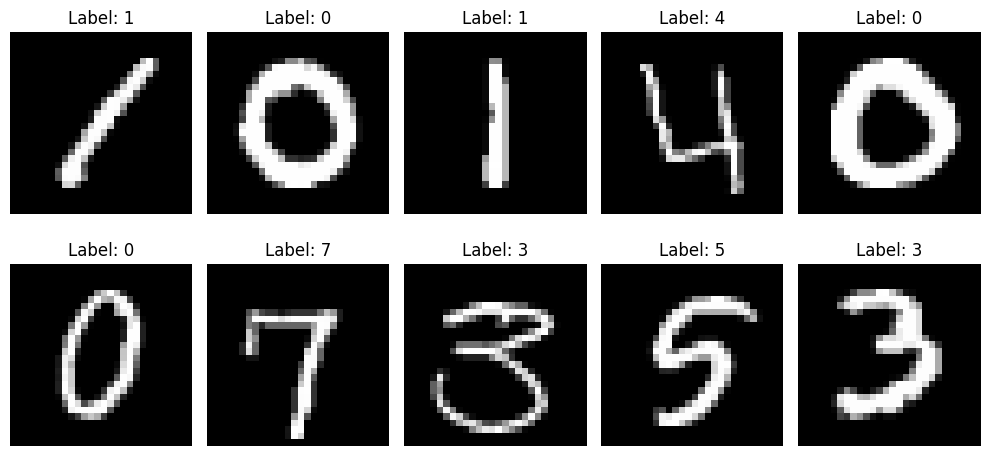

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X.iloc[i].values.reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y.iloc[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
print("Minimum pixel value:", X.min().min())
print("Maximum pixel value:", X.max().max())
print("Average pixel value:", X.mean().mean())

Minimum pixel value: 0
Maximum pixel value: 255
Average pixel value: 33.408911169825075


In [10]:
X = X / 255.0
X_test = X_test / 255.0

print("Minimum:", X.min().min())
print("Maximum:", X.max().max())

Minimum: 0.0
Maximum: 1.0


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)

Training data: (33600, 784)
Validation data: (8400, 784)
Training labels: (33600,)
Validation labels: (8400,)


In [12]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=100,
    solver="lbfgs"
)

print("Training Logistic Regression...")

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Training Logistic Regression...
Baseline model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
from sklearn.metrics import accuracy_score

y_pred = baseline_model.predict(X_val)

baseline_accuracy = accuracy_score(y_val, y_pred)

print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("Baseline Accuracy (%):", round(baseline_accuracy * 100, 2), "%")

Baseline Accuracy: 0.9115
Baseline Accuracy (%): 91.15 %


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Training Random Forest...
Random Forest trained successfully!


In [15]:
rf_pred = rf_model.predict(X_val)

rf_accuracy = accuracy_score(y_val, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest Accuracy (%):", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 0.9639
Random Forest Accuracy (%): 96.39 %


In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("TensorFlow loaded successfully!")

TensorFlow version: 2.20.0
TensorFlow loaded successfully!


In [18]:
X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.values.reshape(-1, 28, 28, 1)

print("Training images:", X_train_cnn.shape)
print("Validation images:", X_val_cnn.shape)

Training images: (33600, 28, 28, 1)
Validation images: (8400, 28, 28, 1)


In [19]:
nn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

nn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = nn_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

print("Neural Network training completed!")

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8590 - loss: 0.5051 - val_accuracy: 0.9255 - val_loss: 0.2564
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9311 - loss: 0.2438 - val_accuracy: 0.9421 - val_loss: 0.1962
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9464 - loss: 0.1846 - val_accuracy: 0.9533 - val_loss: 0.1600
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9560 - loss: 0.1512 - val_accuracy: 0.9590 - val_loss: 0.1370
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9619 - loss: 0.1300 - val_accuracy: 0.9624 - val_loss: 0.1261
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9674 - loss: 0.1107 - val_accuracy: 0.9633 - val_loss: 0.1188
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9716 - loss: 0.0966 - val_accuracy: 0.9669 - val_loss: 0.1076
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9743 - loss: 0.0861 - val_accuracy: 0.

In [21]:
cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

print("CNN training completed!")

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 31s 113ms/step - accuracy: 0.8966 - loss: 0.3428 - val_accuracy: 0.9700 - val_loss: 0.0942
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.9721 - loss: 0.0920 - val_accuracy: 0.9811 - val_loss: 0.0613
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - accuracy: 0.9798 - loss: 0.0656 - val_accuracy: 0.9827 - val_loss: 0.0520
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 37s 108ms/step - accuracy: 0.9844 - loss: 0.0516 - val_accuracy: 0.9855 - val_loss: 0.0489
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 27s 102ms/step - accuracy: 0.9865 - loss: 0.0441 - val_accuracy: 0.9854 - val_loss: 0.0456
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.9885 - loss: 0.0362 - val_accuracy: 0.9882 - val_loss: 0.0380
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.9895 - loss: 0.0322 - val_accuracy: 0.9885 - val_loss: 0.0394
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 27s 103ms/step - accuracy: 0.9917 - loss: 0

In [25]:
import numpy as np
from sklearn.metrics import accuracy_score

cnn_pred_labels = np.argmax(cnn_pred, axis=1)

cnn_accuracy = accuracy_score(y_val, cnn_pred_labels)

print("CNN Accuracy:", round(cnn_accuracy, 4))
print("CNN Accuracy (%):", round(cnn_accuracy * 100, 2), "%")

CNN Accuracy: 0.9892
CNN Accuracy (%): 98.92 %


In [26]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Neural Network",
        "CNN"
    ],
    "Validation Accuracy": [
        baseline_accuracy,
        rf_accuracy,
        0.9693,
        cnn_accuracy
    ]
})

results["Accuracy (%)"] = results["Validation Accuracy"] * 100

print(results.sort_values("Validation Accuracy", ascending=False).to_string(index=False))

              Model  Validation Accuracy  Accuracy (%)
                CNN             0.989167     98.916667
     Neural Network             0.969300     96.930000
      Random Forest             0.963929     96.392857
Logistic Regression             0.911548     91.154762


In [27]:
# Prepare test images for CNN
X_test_cnn = X_test.values.reshape(-1, 28, 28, 1)

print("Test images prepared:", X_test_cnn.shape)

# Generate predictions
test_predictions = cnn_model.predict(X_test_cnn)

# Convert probabilities to digit labels
test_labels = np.argmax(test_predictions, axis=1)

print("Predictions generated successfully!")
print("Number of predictions:", len(test_labels))
print("First 20 predictions:", test_labels[:20])

Test images prepared: (28000, 28, 28, 1)
875/875 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step
Predictions generated successfully!
Number of predictions: 28000
First 20 predictions: [2 0 9 9 3 7 0 3 0 3 5 7 4 0 4 3 3 1 9 0]


In [28]:
submission = pd.DataFrame({
    "ImageId": range(1, len(test_labels) + 1),
    "Label": test_labels
})

submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")
print("Shape:", submission.shape)
print("\nFirst 10 rows:")
print(submission.head(10))

Submission file created successfully!
Shape: (28000, 2)

First 10 rows:
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      9
4        5      3
5        6      7
6        7      0
7        8      3
8        9      0
9       10      3


In [29]:
print("Submission columns:", submission.columns.tolist())
print("Number of rows:", len(submission))
print("Missing values:", submission.isnull().sum().sum())
print("Unique labels:", sorted(submission["Label"].unique()))

print("\nSubmission file:")
print(submission.head())

Submission columns: ['ImageId', 'Label']
Number of rows: 28000
Missing values: 0
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Submission file:
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      9
4        5      3


In [30]:
!kaggle competitions submit -c digit-recognizer -f submission.csv -m "CNN handwritten digit classification"

100% 208k/208k [00:00<00:00, 1.06MB/s]
Successfully submitted to Digit Recognizer